# Customer Churn Prediction - Model Training

## Objective
The objective of this notebook is to build and compare multiple machine learning models for predicting customer churn. A production-ready preprocessing pipeline is used to ensure consistent data transformation during both training and prediction.

## Business Problem
Customer churn directly impacts revenue and customer lifetime value. By training predictive models, the business can identify customers who are likely to churn and take proactive retention measures.

## Import Required Libraries

In [4]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier  
import joblib

## Load the Cleaned Dataset

In [5]:
df = pd.read_csv("../Dataset/processed/telco_customer_churn_cleaned.csv")

df.head()

,customer_id,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,online_security,...,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Separate Features and Target Variable

The feature variables (X) contain customer information used to predict churn, while the target variable (y) represents whether a customer has churned.

In [6]:
X = df.drop(columns=["customer_id", "churn"])
y = df["churn"]
print("Feature Shape :", X.shape)
print("Target Shape :", y.shape)

Feature Shape : (7043, 19)
Target Shape : (7043,)


## Split the Dataset

The dataset is divided into training and testing sets.

- Training data is used to train the model.
- Testing data is used to evaluate how well the model performs on unseen customers.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)
print("Training Set :", X_train.shape)
print("Testing Set :", X_test.shape)

Training Set : (5634, 19)
Testing Set : (1409, 19)


## Identify Numerical and Categorical Features

Before building the preprocessing pipeline, numerical and categorical columns are identified separately. This allows different preprocessing techniques to be applied to each type of feature.

In [8]:
categorical_features = X_train.select_dtypes(include="object").columns.tolist()

numerical_features = X_train.select_dtypes(exclude="object").columns.tolist()

print("Categorical Features")
print(categorical_features)

print()

print("Numerical Features")
print(numerical_features)

Categorical Features
['gender', 'partner', 'dependents', 'phone_service', 'multiple_lines', 'internet_service', 'online_security', 'online_backup', 'device_protection', 'tech_support', 'streaming_tv', 'streaming_movies', 'contract', 'paperless_billing', 'payment_method']

Numerical Features
['senior_citizen', 'tenure', 'monthly_charges', 'total_charges']


C:\Users\Devisri\AppData\Local\Temp\ipykernel_11448\3631030396.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X_train.select_dtypes(include="object").columns.tolist()


## Build the Preprocessing Pipeline

The dataset contains both numerical and categorical features, and each type requires a different preprocessing technique.

- Numerical features are standardized using StandardScaler.
- Categorical features are encoded using OneHotEncoder.

The ColumnTransformer allows different preprocessing techniques to be applied to different groups of columns in a single step. This creates a clean, reusable, and production-ready preprocessing workflow.

In [9]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

## Create the Machine Learning Pipeline

A machine learning pipeline combines preprocessing and model training into a single workflow.

The pipeline ensures that the same preprocessing steps are automatically applied during both training and prediction. This approach improves code readability, reduces preprocessing errors, and makes the workflow suitable for real-world deployment.

In [10]:
logistic_regression_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(random_state=42))
    ]
)

## Train the Logistic Regression Model

The pipeline is trained using the training dataset. During training, the pipeline automatically applies preprocessing before fitting the Logistic Regression model.

In [11]:
logistic_regression_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](2,)","['No','Yes']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['gender','senior_citizen','partner',...,'payment_method', 'monthly_charges','total_charges']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifyin

## Generate Predictions

After training the Logistic Regression model, predictions are generated on the testing dataset. These predictions are used to evaluate how well the model performs on unseen customer data.

In [23]:
y_pred_logistic = logistic_regression_pipeline.predict(X_test)

## Import Evaluation Metrics

The trained model is evaluated using multiple classification metrics to measure its performance on unseen data.

In [13]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

## Evaluate Logistic Regression Model

In [14]:
accuracy = accuracy_score(y_test, y_pred_logistic)

precision = precision_score(y_test, y_pred_logistic, pos_label="Yes")

recall = recall_score(y_test, y_pred_logistic, pos_label="Yes")

f1 = f1_score(y_test, y_pred_logistic, pos_label="Yes")

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Accuracy : 0.8055
Precision: 0.6572
Recall   : 0.5588
F1 Score : 0.6040


## Classification Report

In [15]:
print(classification_report(y_test, y_pred_logistic))

              precision    recall  f1-score   support

          No       0.85      0.89      0.87      1035
         Yes       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



## Confusion Matrix

In [16]:
conf_matrix = confusion_matrix(y_test, y_pred_logistic)

print(conf_matrix)

[[926 109]
 [165 209]]


# 🌳 Model 2: Random Forest Classifier

Random Forest is an ensemble machine learning algorithm that builds multiple decision trees and combines their predictions to improve accuracy and reduce overfitting. It generally performs better than a single decision tree and can capture complex relationships in the data.

In [27]:
random_forest_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=100,
                random_state=42
            )
        )
    ]
)

In [33]:
random_forest_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](2,)","['No','Yes']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['gender','senior_citizen','partner',...,'payment_method', 'monthly_charges','total_charges']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifyin

In [41]:
rf_predictions = random_forest_pipeline.predict(X_test)

In [37]:
rf_accuracy = accuracy_score(y_test, rf_predictions)

print(f"Random Forest Accuracy: {rf_accuracy:.4f}")

Random Forest Accuracy: 0.7864


## Evaluate Random Forest Model

In [61]:
rf_precision = precision_score(
    y_test,
    rf_predictions,
    pos_label="Yes"
)

rf_recall = recall_score(
    y_test,
    rf_predictions,
    pos_label="Yes"
)

rf_f1 = f1_score(
    y_test,
    rf_predictions,
    pos_label="Yes"
)

print(f"Accuracy  : {rf_accuracy:.4f}")
print(f"Precision : {rf_precision:.4f}")
print(f"Recall    : {rf_recall:.4f}")
print(f"F1 Score  : {rf_f1:.4f}")

Accuracy  : 0.7864
Precision : 0.6254
Recall    : 0.4866
F1 Score  : 0.5474


In [40]:
print(classification_report(y_test, rf_predictions))

              precision    recall  f1-score   support

          No       0.83      0.89      0.86      1035
         Yes       0.63      0.49      0.55       374

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.70      1409
weighted avg       0.77      0.79      0.78      1409



## Confusion Matrix

In [42]:
rf_matrix = confusion_matrix(y_test, rf_predictions)

print(rf_matrix)

[[926 109]
 [192 182]]


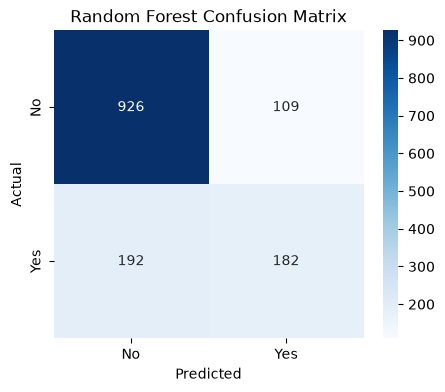

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt

rf_matrix = confusion_matrix(y_test, rf_predictions)

plt.figure(figsize=(5,4))
sns.heatmap(
    rf_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No", "Yes"],
    yticklabels=["No", "Yes"]
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# 🚀 Model 3: XGBoost Classifier
XGBoost (Extreme Gradient Boosting) is an advanced ensemble learning algorithm that builds decision trees sequentially, where each new tree corrects the errors of the previous ones. It is widely used in machine learning competitions and real-world applications due to its high accuracy and efficiency.

In [45]:
xgboost_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            XGBClassifier(
                random_state=42,
                eval_metric="logloss"
            )
        )
    ]
)

## Encode Target Variable for XGBoost

In [47]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

In [49]:
xgboost_pipeline.fit(X_train, y_train_encoded)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['gender','senior_citizen','partner',...,'payment_method', 'monthly_charges','total_charges']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``rema

## Generate Predictions

In [52]:
xgb_predictions = xgboost_pipeline.predict(X_test)

## Decode Predictions

In [54]:
xgb_predictions = label_encoder.inverse_transform(xgb_predictions)

In [55]:
xgb_accuracy = accuracy_score(y_test, xgb_predictions)

xgb_precision = precision_score(
    y_test,
    xgb_predictions,
    pos_label="Yes"
)

xgb_recall = recall_score(
    y_test,
    xgb_predictions,
    pos_label="Yes"
)

xgb_f1 = f1_score(
    y_test,
    xgb_predictions,
    pos_label="Yes"
)

In [56]:
print(classification_report(y_test, xgb_predictions))

              precision    recall  f1-score   support

          No       0.83      0.87      0.85      1035
         Yes       0.58      0.51      0.54       374

    accuracy                           0.77      1409
   macro avg       0.71      0.69      0.70      1409
weighted avg       0.76      0.77      0.77      1409



In [57]:
xgb_matrix = confusion_matrix(y_test, xgb_predictions)

# 📊 Model Comparison

## Compare Model Performance

In [68]:
comparison_df = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        accuracy,
        rf_accuracy,
        xgb_accuracy
    ],
    "Precision": [
        precision,
        rf_precision,
        xgb_precision
    ],
    "Recall": [
        recall,
        rf_recall,
        xgb_recall
    ],
    "F1 Score": [
        f1,
        rf_f1,
        xgb_f1
    ]
})

comparison_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.805536,0.657233,0.558824,0.604046
1,Random Forest,0.786373,0.625430,0.486631,0.547368
2,XGBoost,0.772889,0.582317,0.510695,0.544160


# 💾 Save the Best Model

In [69]:
import joblib

joblib.dump(logistic_regression_pipeline, "best_model.pkl")

print("Best model saved successfully!")

Best model saved successfully!
